<a href="https://colab.research.google.com/github/aabyyaann/UAS-ML/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q tensorflow optuna mlflow lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 705.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.8 MB/s eta 0:00:00
   ━━

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import optuna
import mlflow
import mlflow.tensorflow

from lime.lime_tabular import LimeTabularExplainer

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATA_PATH = "/content/drive/MyDrive/Midterm ML/midterm-regresi-dataset.csv"

df = pd.read_csv(
    DATA_PATH,
    header=None
)

print("Original Shape:", df.shape)
df.head()

Original Shape: (515345, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [7]:
target_col = "Year"
feature_cols = [f"Feature_{i}" for i in range(1, df.shape[1])]

df.columns = [target_col] + feature_cols

print("Dataset shape after renaming:", df.shape)
df.head()

Dataset shape after renaming: (515345, 91)


,Year,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_81,Feature_82,Feature_83,Feature_84,Feature_85,Feature_86,Feature_87,Feature_88,Feature_89,Feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Year        515345 non-null  int64  
 1   Feature_1   515345 non-null  float64
 2   Feature_2   515345 non-null  float64
 3   Feature_3   515345 non-null  float64
 4   Feature_4   515345 non-null  float64
 5   Feature_5   515345 non-null  float64
 6   Feature_6   515345 non-null  float64
 7   Feature_7   515345 non-null  float64
 8   Feature_8   515345 non-null  float64
 9   Feature_9   515345 non-null  float64
 10  Feature_10  515345 non-null  float64
 11  Feature_11  515345 non-null  float64
 12  Feature_12  515345 non-null  float64
 13  Feature_13  515345 non-null  float64
 14  Feature_14  515345 non-null  float64
 15  Feature_15  515345 non-null  float64
 16  Feature_16  515345 non-null  float64
 17  Feature_17  515345 non-null  float64
 18  Feature_18  515345 non-null  float64
 19  Fe

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

print("Total missing values:", missing.sum())
missing.head(10)

Total missing values: 0


,0
Year,0
Feature_1,0
Feature_2,0
Feature_3,0
Feature_4,0
Feature_5,0
Feature_6,0
Feature_7,0
Feature_8,0
Feature_9,0


In [10]:
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 214


In [11]:
df["Year"].describe()

,Year
count,515345.000000
mean,1998.397082
std,10.931046
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000


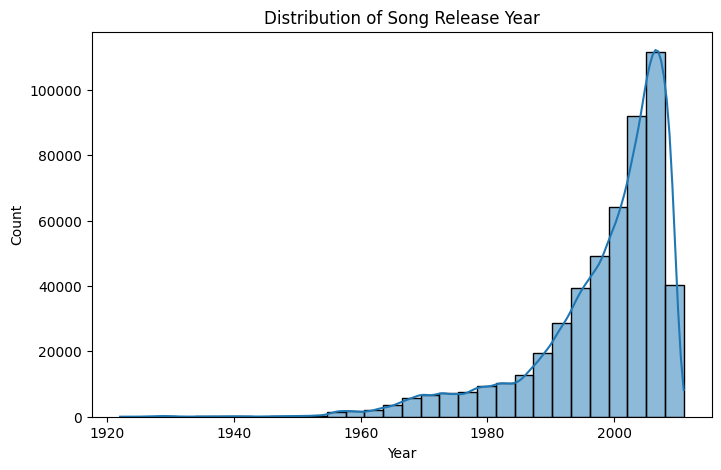

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Year"], bins=30, kde=True)
plt.title("Distribution of Song Release Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

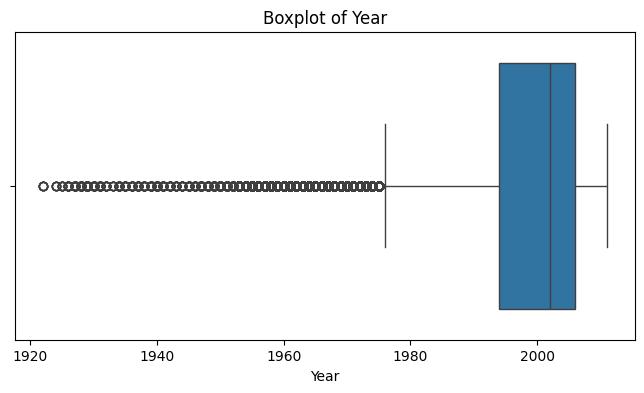

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Year"])
plt.title("Boxplot of Year")
plt.show()

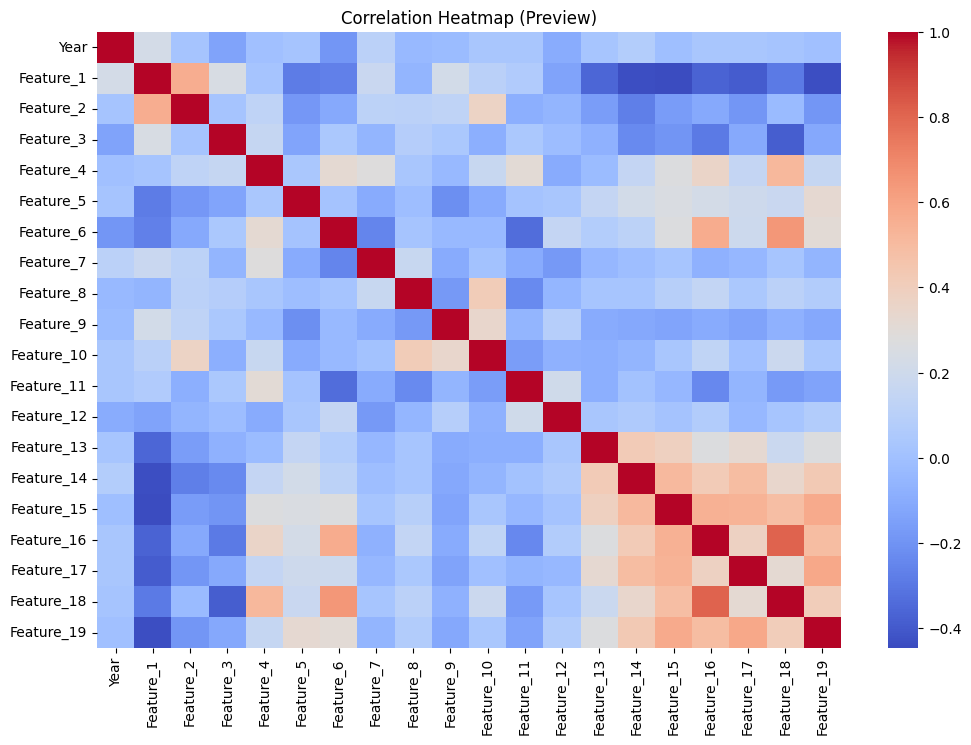

In [14]:
subset_cols = [target_col] + feature_cols[:19]

plt.figure(figsize=(12,8))
corr = df[subset_cols].corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap (Preview)")
plt.show()

In [15]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (515345, 90)
y shape: (515345,)


In [16]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

print("Shape after imputation:", X_imputed.shape)
print("Any NaN left:", np.isnan(X_imputed).sum())

Shape after imputation: (515345, 90)
Any NaN left: 0


In [17]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=SEED
)

print("X_train_full:", X_train_full.shape)
print("X_test_full :", X_test_full.shape)
print("y_train     :", y_train.shape)
print("y_test      :", y_test.shape)

X_train_full: (412276, 90)
X_test_full : (103069, 90)
y_train     : (412276,)
y_test      : (103069,)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (412276, 90)
Scaled test shape : (103069, 90)


In [19]:
X_train_baseline = X_train_scaled.copy()
X_test_baseline = X_test_scaled.copy()

print("Baseline train:", X_train_baseline.shape)
print("Baseline test :", X_test_baseline.shape)

Baseline train: (412276, 90)
Baseline test : (103069, 90)


In [20]:
K_BEST = min(60, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_regression, k=K_BEST)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector.transform(X_test_scaled)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print("Selected feature count:", len(selected_features))
print("Shape after SelectKBest - train:", X_train_kbest.shape)
print("Shape after SelectKBest - test :", X_test_kbest.shape)
print("First 10 selected features:", selected_features[:10])

Selected feature count: 60
Shape after SelectKBest - train: (412276, 60)
Shape after SelectKBest - test : (103069, 60)
First 10 selected features: ['Feature_1', 'Feature_3', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_14', 'Feature_16']


In [21]:
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train_kbest)
X_test_pca = pca.transform(X_test_kbest)

print("PCA train shape:", X_train_pca.shape)
print("PCA test shape :", X_test_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

PCA train shape: (412276, 47)
PCA test shape : (103069, 47)
Explained variance ratio sum: 0.9546225690543757


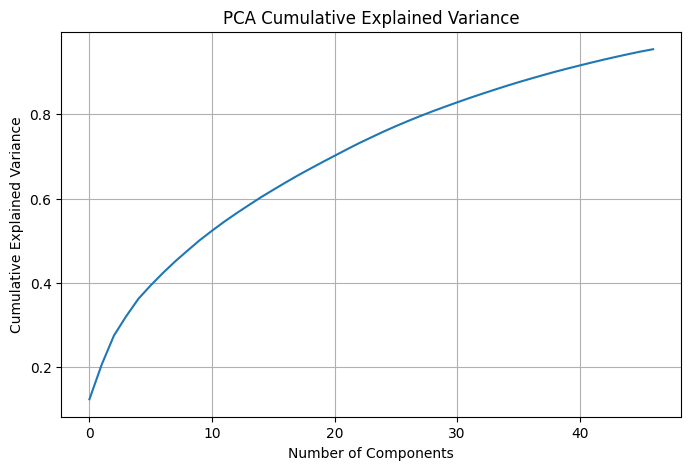

In [22]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [23]:
def build_baseline_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

In [24]:
baseline_model = build_baseline_model(X_train_pca.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [25]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [26]:
history_baseline = baseline_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 985763.3125 - mae: 695.8207 - val_loss: 2438.8459 - val_mae: 31.8781 - learning_rate: 0.0010
Epoch 2/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 60657.1016 - mae: 194.0416 - val_loss: 1330.1393 - val_mae: 22.3047 - learning_rate: 0.0010
Epoch 3/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 53515.3398 - mae: 183.7956 - val_loss: 1030.5422 - val_mae: 20.8167 - learning_rate: 0.0010
Epoch 4/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 50139.6953 - mae: 178.8082 - val_loss: 1166.6183 - val_mae: 26.3922 - learning_rate: 0.0010
Epoch 5/25
1277/1289 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48327.4196 - mae: 175.5611
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 47848.2969 - mae: 174.5791 - val_loss: 1056.4445 - val_mae: 24.7065 - learning_rate: 0.0010
Epoch 6/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 45917.0586 - 

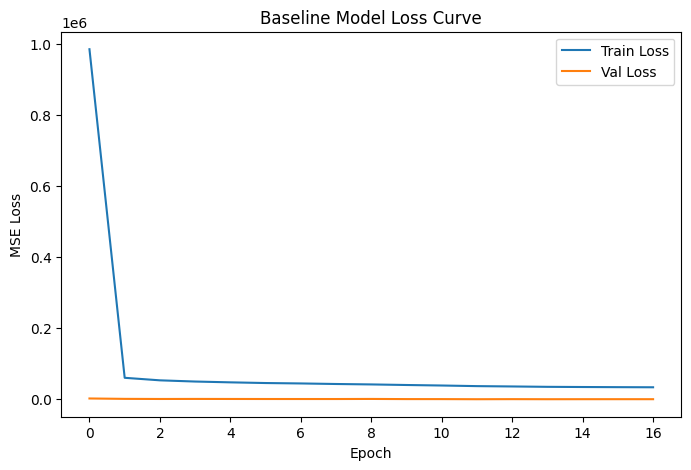

In [27]:
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [28]:
y_pred_baseline = baseline_model.predict(
    X_test_pca,
    verbose=0
).flatten()

print("Prediction sample:", y_pred_baseline[:5])

Prediction sample: [1994.169  1988.9366 1978.5446 1979.3048 1980.4945]


In [29]:
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("=== BASELINE MODEL ===")
print("MSE  :", baseline_mse)
print("RMSE :", baseline_rmse)
print("MAE  :", baseline_mae)
print("R2   :", baseline_r2)

=== BASELINE MODEL ===
MSE  : 324.5959777832031
RMSE : 18.016547332471976
MAE  : 13.957283020019531
R2   : -1.7273533344268799


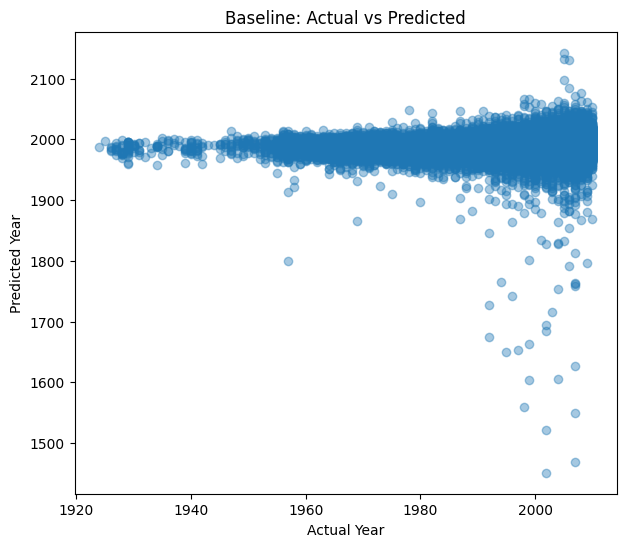

In [30]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_baseline, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Baseline: Actual vs Predicted")
plt.show()

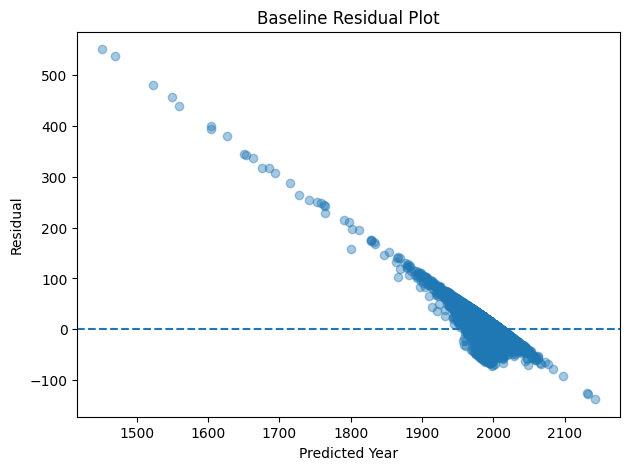

In [31]:
baseline_residuals = y_test - y_pred_baseline

plt.figure(figsize=(7,5))
plt.scatter(y_pred_baseline, baseline_residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Baseline Residual Plot")
plt.show()

In [32]:
def objective(trial):
    units1 = trial.suggest_categorical("units1", [64, 128, 256])
    units2 = trial.suggest_categorical("units2", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)

    model = Sequential([
        Input(shape=(X_train_pca.shape[1],)),
        Dense(units1, activation="relu"),
        BatchNormalization(),
        Dropout(dropout),

        Dense(units2, activation="relu"),
        Dropout(dropout),

        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        X_train_pca,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=256,
        verbose=0
    )

    return min(history.history["val_loss"])

In [33]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=8)

best_params = study.best_params
print("Best Params:", best_params)

[I 2026-06-22 07:59:06,004] A new study created in memory with name: no-name-e301dcbe-fc54-45d7-8e0e-eebd2bbbe22b
[I 2026-06-22 08:00:11,017] Trial 0 finished with value: 1605.09716796875 and parameters: {'units1': 256, 'units2': 32, 'dropout': 0.3082476821807455, 'lr': 0.00038541690165342274}. Best is trial 0 with value: 1605.09716796875.
[I 2026-06-22 08:01:09,225] Trial 1 finished with value: 4741.75244140625 and parameters: {'units1': 128, 'units2': 64, 'dropout': 0.3687345635772671, 'lr': 0.00010783785874580993}. Best is trial 0 with value: 1605.09716796875.
[I 2026-06-22 08:02:14,738] Trial 2 finished with value: 1256.46875 and parameters: {'units1': 128, 'units2': 128, 'dropout': 0.2671429835014988, 'lr': 0.00015527324938227805}. Best is trial 2 with value: 1256.46875.
[I 2026-06-22 08:03:14,237] Trial 3 finished with value: 4250.2919921875 and parameters: {'units1': 64, 'units2': 128, 'dropout': 0.36339308264910997, 'lr': 0.00013620563345839734}. Best is trial 2 with value: 125

Best Params: {'units1': 128, 'units2': 64, 'dropout': 0.10139413580428316, 'lr': 0.0005929397765279976}


In [34]:
best_model = Sequential([
    Input(shape=(X_train_pca.shape[1],)),

    Dense(best_params["units1"], activation="relu"),
    BatchNormalization(),
    Dropout(best_params["dropout"]),

    Dense(best_params["units2"], activation="relu"),
    Dropout(best_params["dropout"]),

    Dense(1, activation="linear")
])

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["lr"]),
    loss="mse",
    metrics=["mae"]
)

best_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [35]:
history_best = best_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1582346.3750 - mae: 1018.5837 - val_loss: 88134.4453 - val_mae: 200.5754 - learning_rate: 5.9294e-04
Epoch 2/25
1284/1289 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63088.8210 - mae: 186.8617
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00029646989423781633.
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 45948.2031 - mae: 162.1023 - val_loss: 1387.5114 - val_mae: 23.0756 - learning_rate: 5.9294e-04
Epoch 3/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 33589.0664 - mae: 142.3862 - val_loss: 837.5828 - val_mae: 20.4436 - learning_rate: 2.9647e-04
Epoch 4/25
1284/1289 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32042.0227 - mae: 139.8455
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00014823494711890817.
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 31335.9902 - mae: 138.6112 - val_loss: 670.9076 - val_mae: 18.4208 - learning_rate: 2.9647e-04
Epoch 5/25
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step -

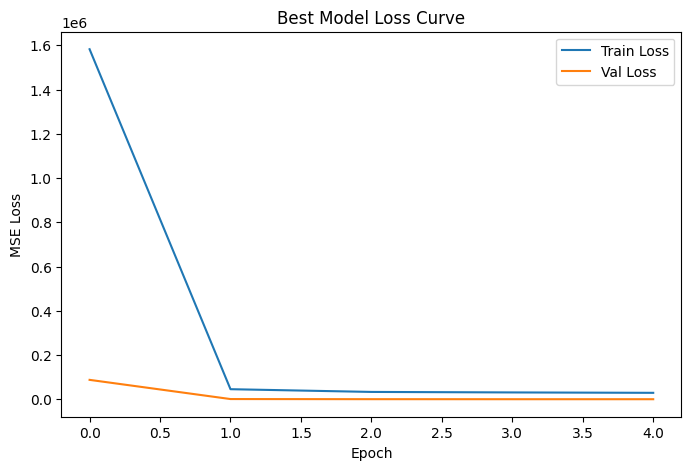

In [36]:
plt.figure(figsize=(8,5))
plt.plot(history_best.history["loss"], label="Train Loss")
plt.plot(history_best.history["val_loss"], label="Val Loss")
plt.title("Best Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [37]:
y_pred_best = best_model.predict(
    X_test_pca,
    verbose=0
).flatten()

print("Prediction sample:", y_pred_best[:5])

Prediction sample: [1120.4897 1155.9983 2105.2922 1909.0845 1700.7386]


In [38]:
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print("=== BEST MODEL ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

=== BEST MODEL ===
MSE  : 88458.71875
RMSE : 297.42010481808387
MAE  : 200.8347625732422
R2   : -742.2568359375


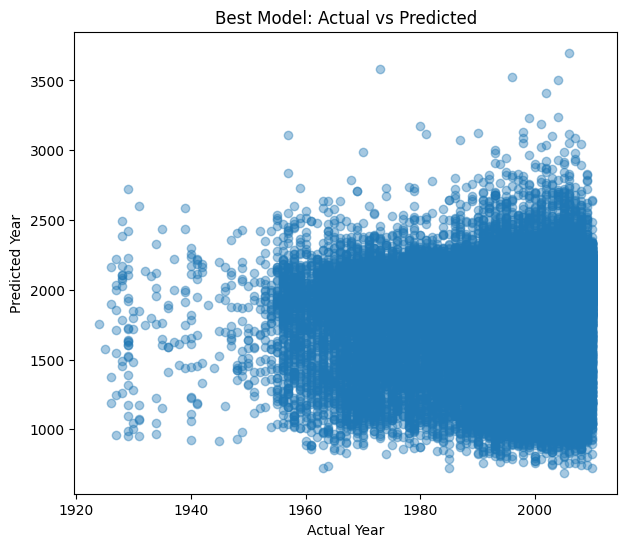

In [39]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Best Model: Actual vs Predicted")
plt.show()

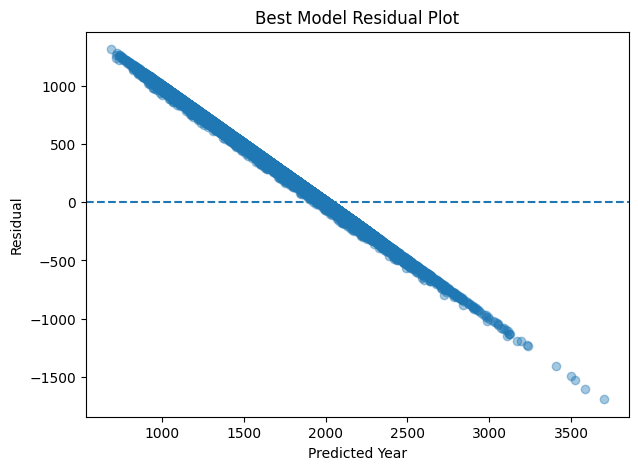

In [40]:
best_residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))
plt.scatter(y_pred_best, best_residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Best Model Residual Plot")
plt.show()

In [41]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Best Optuna"],
    "MSE": [baseline_mse, mse],
    "RMSE": [baseline_rmse, rmse],
    "MAE": [baseline_mae, mae],
    "R2": [baseline_r2, r2]
})

comparison_df

,Model,MSE,RMSE,MAE,R2
0,Baseline,324.595978,18.016547,13.957283,-1.727353
1,Best Optuna,88458.718750,297.420105,200.834763,-742.256836


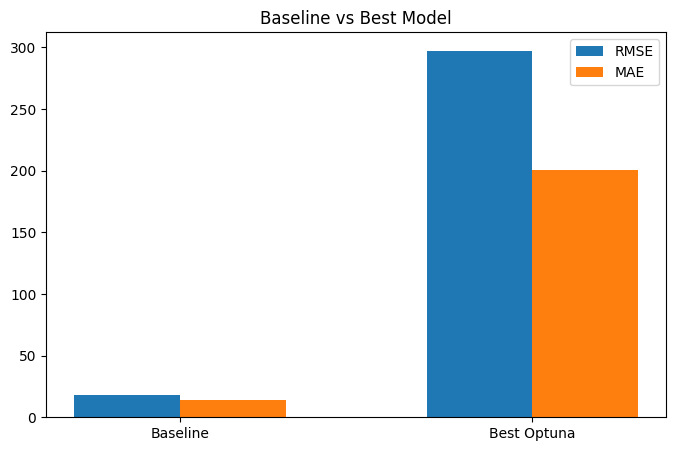

In [42]:
plt.figure(figsize=(8,5))
x = np.arange(len(comparison_df["Model"]))

plt.bar(x - 0.15, comparison_df["RMSE"], width=0.3, label="RMSE")
plt.bar(x + 0.15, comparison_df["MAE"], width=0.3, label="MAE")

plt.xticks(x, comparison_df["Model"])
plt.title("Baseline vs Best Model")
plt.legend()
plt.show()

In [43]:
mlflow.set_experiment("Song_Year_Prediction")

with mlflow.start_run():
    mlflow.log_param("feature_selection_k", K_BEST)
    mlflow.log_param("pca_n_components", X_train_pca.shape[1])

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    mlflow.log_metric("baseline_rmse", baseline_rmse)
    mlflow.log_metric("baseline_mae", baseline_mae)
    mlflow.log_metric("baseline_r2", baseline_r2)

    mlflow.log_metric("best_mse", mse)
    mlflow.log_metric("best_rmse", rmse)
    mlflow.log_metric("best_mae", mae)
    mlflow.log_metric("best_r2", r2)

    mlflow.tensorflow.log_model(best_model, "song_year_model")

print("MLflow logging selesai")

2026/06/22 08:07:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 08:07:17 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 08:07:21 INFO mlflow.tracking.fluent: Experiment with name 'Song_Year_Prediction' does not exist. Creating a new experiment.
2026/06/22 08:07:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 08:07:21 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow logging selesai


In [44]:
explainer = LimeTabularExplainer(
    training_data=X_train_pca,
    mode="regression",
    feature_names=[f"PC_{i+1}" for i in range(X_train_pca.shape[1])]
)

print("LIME explainer berhasil dibuat")

LIME explainer berhasil dibuat


In [45]:
exp = explainer.explain_instance(
    data_row=X_test_pca[0],
    predict_fn=lambda x: best_model.predict(x, verbose=0).flatten(),
    num_features=min(10, X_test_pca.shape[1])
)

print("LIME explanation for first test sample:")
for item in exp.as_list():
    print(item)

LIME explanation for first test sample:
('PC_2 <= -0.94', -198.13974463600158)
('PC_4 <= -0.77', -134.87015927172763)
('PC_5 > 0.71', -110.96926646765343)
('PC_21 <= -0.49', 63.72084773995326)
('PC_23 <= -0.48', -62.50962477148437)
('-1.82 < PC_1 <= -0.61', 54.14037120733123)
('PC_10 <= -0.68', -49.84404286031643)
('PC_42 <= -0.33', 49.07684513894413)
('PC_7 <= -0.69', -46.285161203998996)
('PC_13 > 0.53', 44.63398930490699)


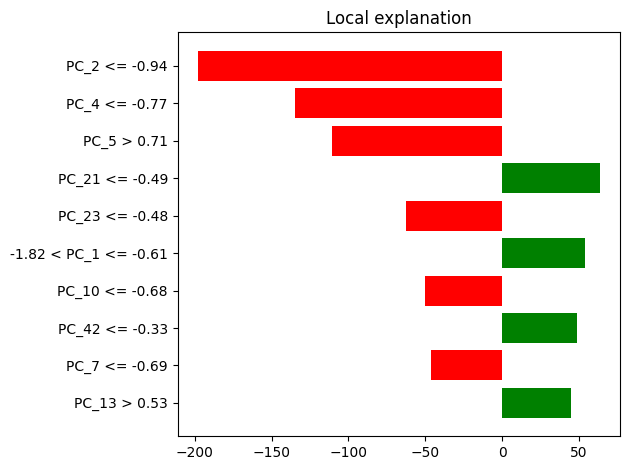

In [46]:
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [47]:
best_model.save("song_year_regression_model.keras")
print("Model saved: song_year_regression_model.keras")

Model saved: song_year_regression_model.keras


In [48]:
result_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2"],
    "Value": [mse, rmse, mae, r2]
})

result_df.to_csv("regression_metrics.csv", index=False)

result_df

,Metric,Value
0,MSE,88458.718750
1,RMSE,297.420105
2,MAE,200.834763
3,R2,-742.256836


In [49]:
prediction_df = pd.DataFrame({
    "Actual_Year": y_test.values[:100],
    "Predicted_Year": y_pred_best[:100]
})

prediction_df.to_csv("sample_predictions.csv", index=False)
prediction_df.head()

,Actual_Year,Predicted_Year
0,2008,1120.489746
1,2001,1155.998291
2,2006,2105.292236
3,2008,1909.084473
4,1998,1700.738647


In [50]:
print("===== SUMMARY =====")
print("1. Data berhasil dimuat dan dipreproses.")
print("2. Feature selection dilakukan dengan SelectKBest.")
print("3. Dimensionality reduction dilakukan dengan PCA.")
print("4. Baseline model dan tuned model dibandingkan.")
print("5. Hyperparameter tuning dilakukan menggunakan Optuna.")
print("6. Hasil model dilacak menggunakan MLflow.")
print("7. Interpretasi lokal dilakukan menggunakan LIME.")
print("8. Model dan hasil evaluasi berhasil disimpan.")

===== SUMMARY =====
1. Data berhasil dimuat dan dipreproses.
2. Feature selection dilakukan dengan SelectKBest.
3. Dimensionality reduction dilakukan dengan PCA.
4. Baseline model dan tuned model dibandingkan.
5. Hyperparameter tuning dilakukan menggunakan Optuna.
6. Hasil model dilacak menggunakan MLflow.
7. Interpretasi lokal dilakukan menggunakan LIME.
8. Model dan hasil evaluasi berhasil disimpan.


In [51]:
del X_imputed
del X_train_full, X_test_full
gc.collect()

print("Memory cleanup selesai")

Memory cleanup selesai
